LPRNet завантажено!


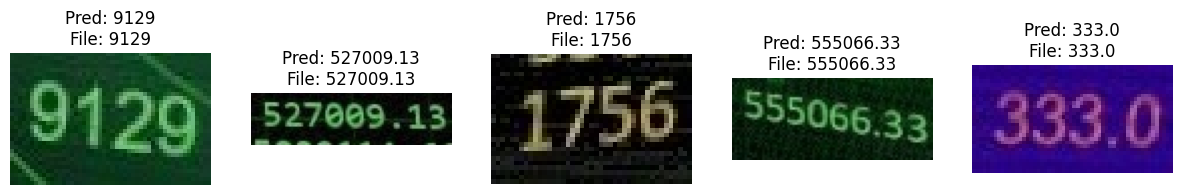

In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import sys

# --- НАЛАШТУВАННЯ ---
LPRNET_REPO_PATH = 'LPRNet_Pytorch'
WEIGHTS_PATH = 'weights/lprnet_best.pth'
CROPS_DIR = 'lpr_datasets/lprnet/crops' # Папка з нарізаними картинками
IMG_SIZE = (94, 24)
CHARS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-', '.']
LPR_MAX_LEN = 18

# Імпорт моделі
if LPRNET_REPO_PATH not in sys.path:
    sys.path.append(LPRNET_REPO_PATH)
from model.LPRNet import LPRNet

# --- ФУНКЦІЯ ДЕКОДУВАННЯ (Числа -> Текст) ---
def decode(preds, chars):
    # preds: [1, Class_Num, Time] (raw logits)
    preds = preds.cpu().detach().numpy()
    pred_labels = np.argmax(preds, axis=1) # [1, Time]

    decoded_strings = []
    for i in range(pred_labels.shape[0]):
        line = pred_labels[i, :]
        res = []
        # Логіка CTC: видаляємо дублікати підряд, потім blank
        # Blank token index = len(chars)
        blank_idx = len(chars)

        pre_c = -1
        for c in line:
            if c != pre_c and c != blank_idx:
                res.append(chars[c])
            pre_c = c
        decoded_strings.append("".join(res))

    return decoded_strings[0]

# --- ЗАВАНТАЖЕННЯ МОДЕЛІ ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lprnet = LPRNet(lpr_max_len=LPR_MAX_LEN, phase=False, class_num=len(CHARS)+1, dropout_rate=0).to(device)
lprnet.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
lprnet.eval()
print("LPRNet завантажено!")

# --- ТЕСТ НА 5 ВИПАДКОВИХ КАРТИНКАХ ---
files = [f for f in os.listdir(CROPS_DIR) if f.endswith('.jpg')]
if not files:
    print("Не знайдено картинок!")
else:
    random_files = random.sample(files, 5)

    plt.figure(figsize=(15, 5))

    for idx, fname in enumerate(random_files):
        # Читаємо
        img_path = os.path.join(CROPS_DIR, fname)
        img = cv2.imread(img_path)

        # Препроцесинг
        x = cv2.resize(img, IMG_SIZE)
        x = x.astype('float32')
        x -= 127.5
        x *= 0.0078125
        x = np.transpose(x, (2, 0, 1))
        x = torch.from_numpy(x).unsqueeze(0).to(device) # [1, 3, 24, 94]

        # Передбачення
        pred = lprnet(x)
        text = decode(pred, CHARS)

        # Відображення
        plt.subplot(1, 5, idx+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Pred: {text}\nFile: {fname.split('_')[-1][:-4]}")
        plt.axis('off')

    plt.show()

Завантаження YOLO...
Завантаження LPRNet...
Обробка 6 зображень...


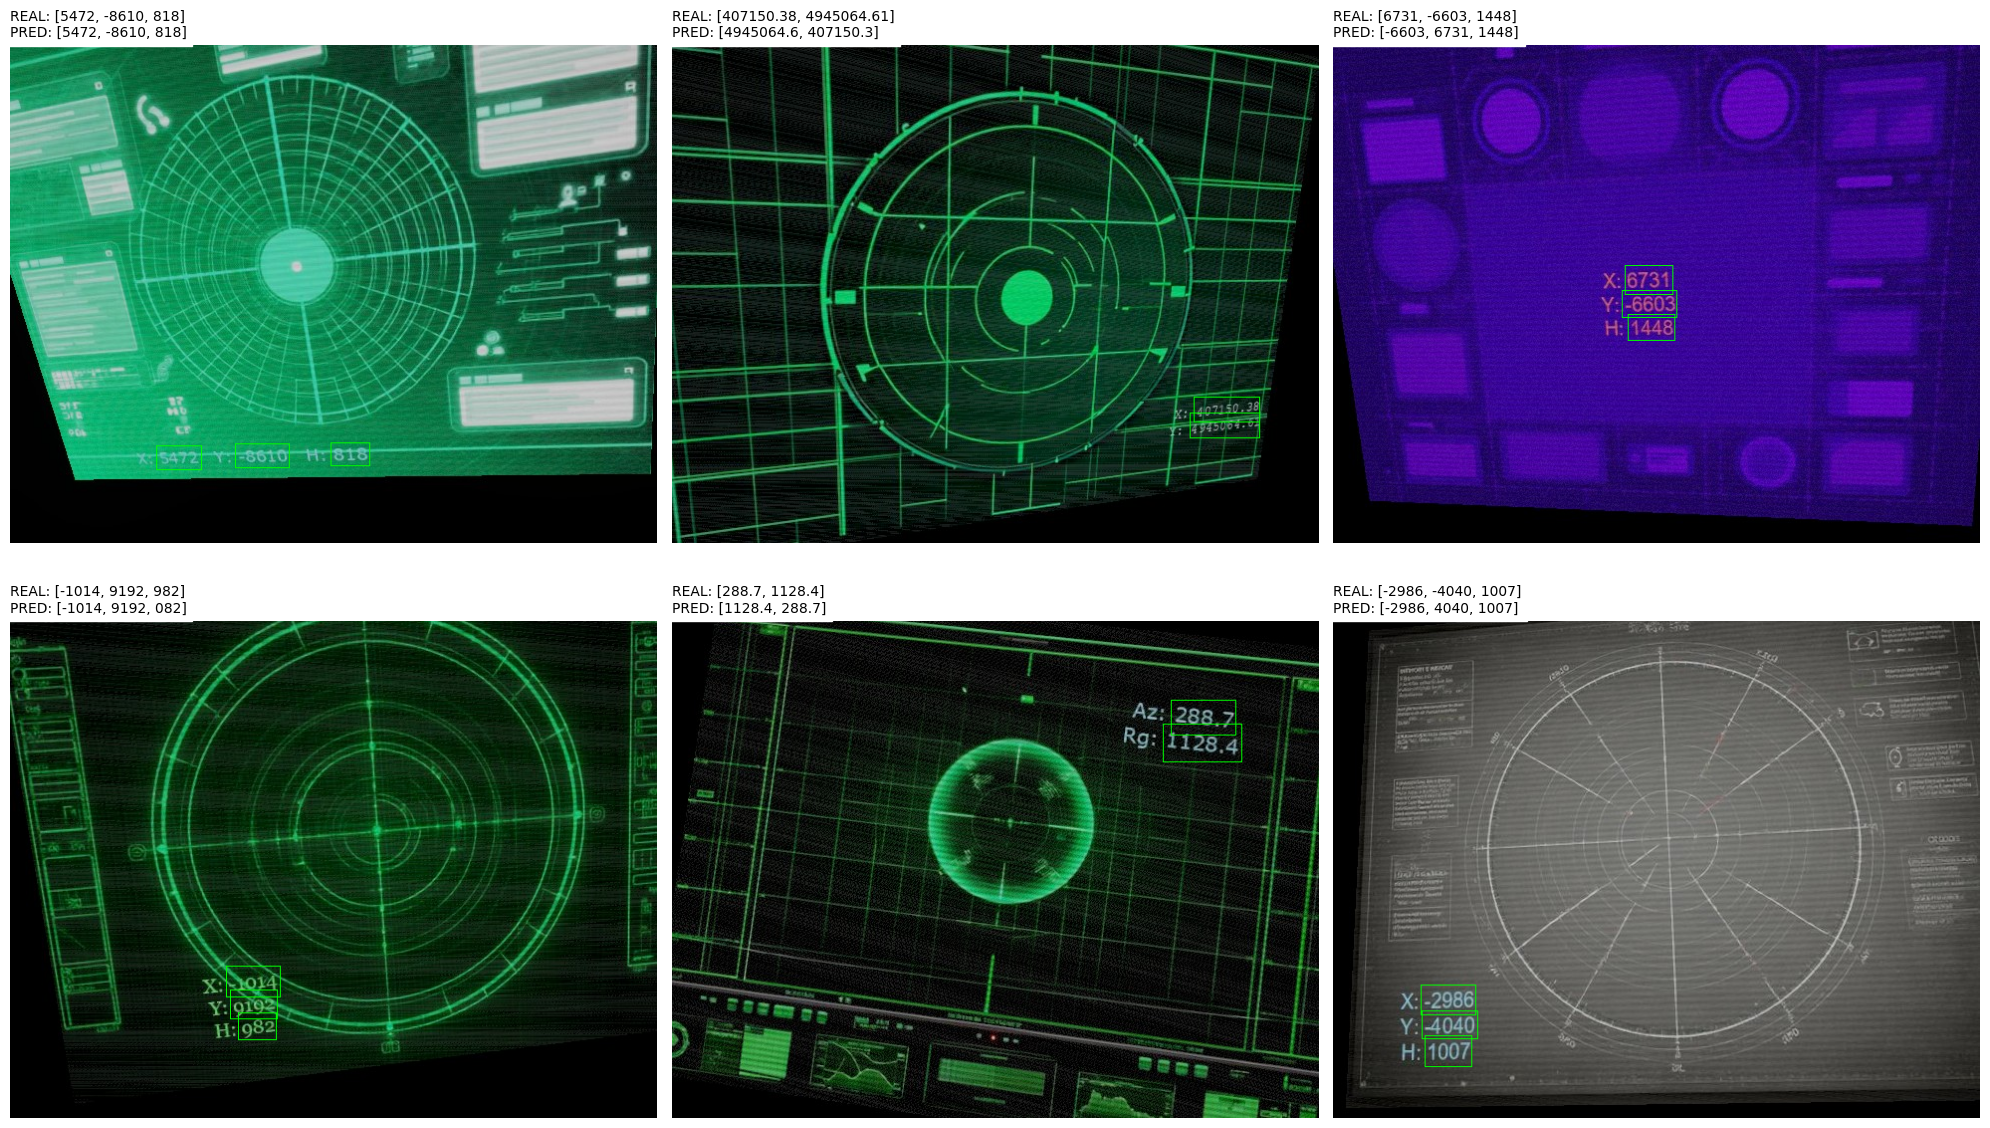

In [5]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import random
import json
from glob import glob
from ultralytics import YOLO

# --- КОНФІГИ ---
# Перевір шляхи перед запуском!
YOLO_WEIGHTS = 'yolo_project/runs/exp_numbers/weights/best.pt'
LPR_WEIGHTS = 'weights/lprnet_best.pth'
LPRNET_REPO_PATH = 'LPRNet_Pytorch'

IMAGES_DIR = 'unity/images'
LABELS_DIR = 'unity/labels' # Потрібно для виводу "що має бути"

CHARS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-', '.']
IMG_SIZE = (94, 24)

# --- ІМПОРТИ ---
if LPRNET_REPO_PATH not in sys.path:
    sys.path.append(LPRNET_REPO_PATH)
from model.LPRNet import LPRNet

# --- ФУНКЦІЇ ---

def is_number(text):
    allowed = set("0123456789.-")
    return all(c in allowed for c in text) and len(text) > 0

def get_ground_truth(img_path):
    """Витягує правильні числа з JSON файлу"""
    base_name = os.path.basename(img_path).replace('.jpg', '').replace('.png', '')
    json_path = os.path.join(LABELS_DIR, base_name + '.json')

    true_numbers = []

    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
            # Припускаємо структуру як раніше: список об'єктів -> data_raw -> групи
            for item in data:
                if 'data_raw' in item:
                    for group in item['data_raw']:
                        for text in group:
                            if is_number(text):
                                true_numbers.append(text)
    return true_numbers

def decode(preds):
    preds = preds.cpu().detach().numpy()
    pred_labels = np.argmax(preds, axis=1)
    decoded = []
    blank_idx = len(CHARS)
    for i in range(pred_labels.shape[0]):
        line = pred_labels[i, :]
        res = []
        pre_c = -1
        for c in line:
            if c != pre_c and c != blank_idx:
                res.append(CHARS[c])
            pre_c = c
        decoded.append("".join(res))
    return decoded[0]

# --- ЗАВАНТАЖЕННЯ МОДЕЛЕЙ ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Завантаження YOLO...")
yolo_model = YOLO(YOLO_WEIGHTS)

print("Завантаження LPRNet...")
lprnet = LPRNet(lpr_max_len=18, phase=False, class_num=len(CHARS)+1, dropout_rate=0).to(device)
lprnet.load_state_dict(torch.load(LPR_WEIGHTS, map_location=device))
lprnet.eval()

# --- ОСНОВНИЙ ЦИКЛ ---
all_images = glob(os.path.join(IMAGES_DIR, '*.jpg'))
if len(all_images) == 0:
    all_images = glob(os.path.join(IMAGES_DIR, '*.png'))

# Вибираємо 6 випадкових
if len(all_images) >= 6:
    samples = random.sample(all_images, 6)
else:
    samples = all_images

# Створюємо сітку для малювання (2 рядки по 3 колонки)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# Робимо список плоским, щоб зручно ітеруватися
axes = axes.flatten()

print(f"Обробка {len(samples)} зображень...")

for ax, img_path in zip(axes, samples):
    img = cv2.imread(img_path)
    # Копія для малювання
    draw_img = img.copy()

    # 1. Отримуємо Ground Truth (що має бути)
    gt_texts = get_ground_truth(img_path)

    # 2. Передбачення (YOLO)
    results = yolo_model(img, verbose=False)[0]
    boxes = results.boxes.xyxy.cpu().numpy().astype(int)

    # Сортуємо бокси зліва-направо (по X), щоб порядок збігався з читанням
    boxes = sorted(boxes, key=lambda b: b[0])

    found_texts = []

    for box in boxes:
        x1, y1, x2, y2 = box

        # Обрізаємо вихід за межі
        h, w, _ = img.shape
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        # Кроп і LPRNet
        crop = img[y1:y2, x1:x2]
        if crop.size == 0: continue

        crop_resized = cv2.resize(crop, IMG_SIZE)
        blob = crop_resized.astype('float32')
        blob -= 127.5
        blob *= 0.0078125
        blob = np.transpose(blob, (2, 0, 1))
        blob = torch.from_numpy(blob).unsqueeze(0).to(device)

        with torch.no_grad():
            preds = lprnet(blob)
            text = decode(preds)
            found_texts.append(text)

        # Малюємо ТОНКУ рамку (thickness=1)
        cv2.rectangle(draw_img, (x1, y1), (x2, y2), (0, 255, 0), 1)

    # 3. Візуалізація
    # Конвертуємо BGR в RGB для matplotlib
    draw_img = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

    ax.imshow(draw_img)

    # Формуємо текст заголовка
    # Join список у рядок для краси
    gt_str = ", ".join(gt_texts) if gt_texts else "???"
    pred_str = ", ".join(found_texts) if found_texts else "Not found"

    # Колір заголовка: якщо збігається кількість знайдених - зелений, інакше червоний
    title_color = 'green' if len(gt_texts) == len(found_texts) else 'red'

    title_text = f"REAL: [{gt_str}]\nPRED: [{pred_str}]"
    ax.set_title(title_text, fontsize=10, color='black', backgroundcolor='white', loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()